# E-Commerce Revenue Analysis 📊

## Objective
The goal of this project is to analyze an e-commerce dataset to understand:
- How revenue is generated across product categories
- Which categories contribute the most to total revenue
- Business insights that can help improve sales strategy

This analysis uses Python, Pandas, and basic data visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Data Preparation

To calculate revenue by product category:
- Order items are merged with product information
- Product category names are translated to English

In [4]:
items_products = items.merge(
    products,
    on="product_id",
    how="left"
)

items_products = items_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

## Revenue Calculation

Revenue is calculated using the price of each ordered item.

In [5]:
category_revenue = (
    items_products
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

In [6]:
category_revenue_percent = (
    category_revenue / category_revenue.sum() * 100
)

category_revenue_percent.head(10)

product_category_name_english
health_beauty            9.388524
watches_gifts            8.988157
bed_bath_table           7.734915
sports_leisure           7.369873
computers_accessories    6.802282
furniture_decor          5.443310
cool_stuff               4.738645
housewares               4.715953
auto                     4.421109
garden_tools             3.619536
Name: price, dtype: float64

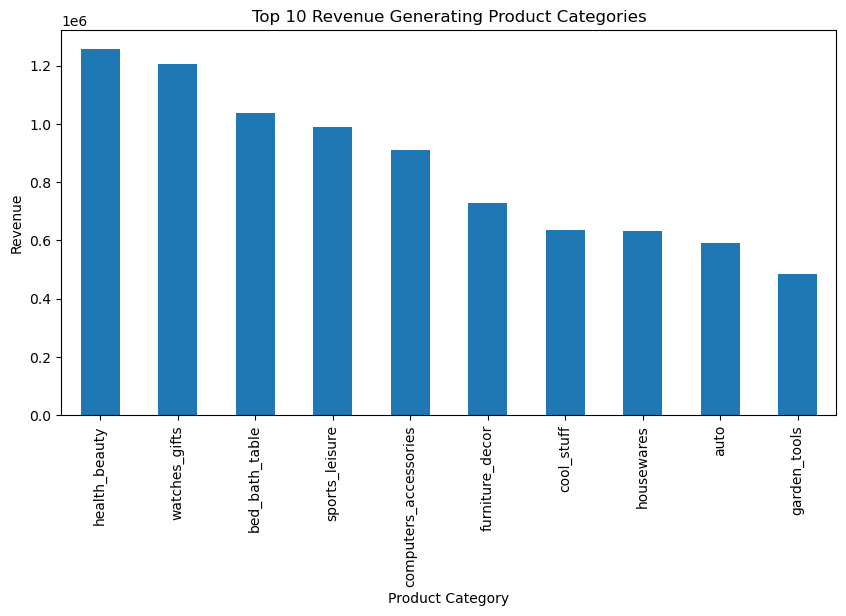

In [7]:
category_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Revenue Generating Product Categories")
plt.ylabel("Revenue")
plt.xlabel("Product Category")
plt.show()

## Key Insights

- Health & Beauty and Watches & Gifts are the highest revenue-generating categories.
- A small number of categories contribute a large percentage of total revenue.
- Focusing marketing and inventory efforts on top categories can significantly increase overall revenue.

This analysis demonstrates how data can support business decision-making.